# Repository Popularity Metrics at Security-Fix Commit Time

This notebook summarizes repository popularity metrics mined at each CVE security-fix commit time. It reports median/IQR values and creates violin and boxplot visuals for each popularity metric.

Metrics used:
- Stars
- Forks
- Closed pull requests
- Closed issues
- Commits
- Contributors

Plots use `log10(value + 1)` scaling because repository popularity metrics are strongly right-skewed.

In [14]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [15]:
INPUT_CSV = Path('../../data/rq1/repo_popularity_at_fix_commit.csv')

popularity_df = pd.read_csv(INPUT_CSV)
print('Rows:', len(popularity_df))
print('Unique CVEs:', popularity_df['CVE_ID'].nunique())
print('Unique repositories:', popularity_df['repository'].nunique())
print(popularity_df.columns.tolist())
popularity_df.head()

Rows: 832
Unique CVEs: 832
Unique repositories: 257
['CVE_ID', 'PATCH', 'repository', 'owner', 'repo', 'commit_sha', 'commit_time', 'stars_count_at_commit', 'forks_count_at_commit', 'closed_prs_count_at_commit', 'closed_issues_count_at_commit', 'commits_count_at_commit', 'contributors_count_at_commit', 'metric_status', 'metric_error', 'stars_status', 'forks_status', 'closed_prs_status', 'closed_issues_status', 'commits_status', 'contributors_status', 'batch_source_file']


,CVE_ID,PATCH,repository,owner,repo,commit_sha,commit_time,stars_count_at_commit,forks_count_at_commit,closed_prs_count_at_commit,...,contributors_count_at_commit,metric_status,metric_error,stars_status,forks_status,closed_prs_status,closed_issues_status,commits_status,contributors_status,batch_source_file
0,CVE-2013-4600,https://github.com/alkacon/opencms-core/commit...,alkacon/opencms-core,alkacon,opencms-core,72a05e3ea1cf692e2efce002687272e63f98c14a,2013-06-20T13:32:02Z,72.0,42.0,38.0,...,57.0,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,runtime_results
1,CVE-2018-3831,https://github.com/elastic/elasticsearch/commi...,elastic/elasticsearch,elastic,elasticsearch,cfe3d9f611a328cfffc18b445b3aecb016349514,2018-08-29T20:31:56Z,30889.0,9409.0,15851.0,...,1203.0,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,runtime_results
2,CVE-2013-4310,https://github.com/apache/struts/commit/0c8366...,apache/struts,apache,struts,0c8366cb792227d484b9ca13e537037dd0cb57dc,2013-10-15T18:20:43Z,0.0,0.0,0.0,...,32.0,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,runtime_results
3,CVE-2018-1000615,https://github.com/opennetworkinglab/onos/comm...,opennetworkinglab/onos,opennetworkinglab,onos,1a783729a1d7e0cd59d59a8dd3a73cdd6ac0f30d,2018-06-27T21:07:37Z,447.0,332.0,24.0,...,363.0,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,runtime_results
4,CVE-2022-23596,https://github.com/junrar/junrar/commit/7b16b3...,junrar/junrar,junrar,junrar,7b16b3d90b91445fd6af0adfed22c07413d4fab7,2022-01-27T04:08:38Z,181.0,52.0,43.0,...,23.0,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,runtime_results


## Metric Columns and Data Availability

In [16]:
metric_columns = {
    'Stars': 'stars_count_at_commit',
    'Forks': 'forks_count_at_commit',
    'Closed PRs': 'closed_prs_count_at_commit',
    'Closed Issues': 'closed_issues_count_at_commit',
    'Commits': 'commits_count_at_commit',
    'Contributors': 'contributors_count_at_commit',
}

status_columns = {
    'Stars': 'stars_status',
    'Forks': 'forks_status',
    'Closed PRs': 'closed_prs_status',
    'Closed Issues': 'closed_issues_status',
    'Commits': 'commits_status',
    'Contributors': 'contributors_status',
}

# Ensure numeric metric columns.
for metric, column in metric_columns.items():
    popularity_df[column] = pd.to_numeric(popularity_df[column], errors='coerce')

availability_rows = []
for metric, column in metric_columns.items():
    status_column = status_columns[metric]
    values = popularity_df[column]
    availability_rows.append({
        'Metric': metric,
        'Metric column': column,
        'Non-null count': int(values.notna().sum()),
        'Missing count': int(values.isna().sum()),
        'Metric-status ok count': int(popularity_df[status_column].eq('ok').sum()) if status_column in popularity_df.columns else pd.NA,
        'Metric-status missing count': int(popularity_df[status_column].isna().sum()) if status_column in popularity_df.columns else pd.NA,
    })

availability_table = pd.DataFrame(availability_rows)
availability_table

,Metric,Metric column,Non-null count,Missing count,Metric-status ok count,Metric-status missing count
0,Stars,stars_count_at_commit,825,7,807,18
1,Forks,forks_count_at_commit,827,5,809,18
2,Closed PRs,closed_prs_count_at_commit,764,68,746,18
3,Closed Issues,closed_issues_count_at_commit,764,68,746,18
4,Commits,commits_count_at_commit,827,5,809,18
5,Contributors,contributors_count_at_commit,827,5,809,18


## Median and IQR Summary

The summary uses non-null numeric values for each metric. This avoids dropping valid metric values where a status field is blank but the count was successfully mined.

In [17]:
def metric_summary(values):
    values = values.dropna()
    return {
        'n': int(len(values)),
        'median': values.median(),
        'q1': values.quantile(0.25),
        'q3': values.quantile(0.75),
        'mean': values.mean(),
        'min': values.min(),
        'max': values.max(),
    }

summary_rows = []
for metric, column in metric_columns.items():
    stats = metric_summary(popularity_df[column])
    summary_rows.append({
        'Metric': metric,
        'n': stats['n'],
        'Median': stats['median'],
        'IQR': f"[{stats['q1']:.2f}, {stats['q3']:.2f}]",
        'Q1': stats['q1'],
        'Q3': stats['q3'],
        'Mean': stats['mean'],
        'Min': stats['min'],
        'Max': stats['max'],
    })

popularity_median_iqr_table = pd.DataFrame(summary_rows)
popularity_median_iqr_table

,Metric,n,Median,IQR,Q1,Q3,Mean,Min,Max
0,Stars,825,566.0,"[81.00, 1872.00]",81.0,1872.00,2204.191515,0.0,38978.0
1,Forks,827,285.0,"[44.00, 1016.00]",44.0,1016.00,1126.926239,0.0,26278.0
2,Closed PRs,764,183.0,"[10.00, 792.75]",10.0,792.75,1050.556283,0.0,27943.0
3,Closed Issues,764,0.0,"[0.00, 194.25]",0.0,194.25,906.604712,0.0,19854.0
4,Commits,827,5461.0,"[2652.00, 12923.50]",2652.0,12923.50,10384.062878,0.0,485213.0
5,Contributors,827,71.0,"[30.00, 174.50]",30.0,174.50,139.321644,0.0,2044.0


## Long-Format Data for Plots

In [18]:
plot_rows = []
for metric, column in metric_columns.items():
    metric_df = popularity_df[['CVE_ID', 'repository', column]].copy()
    metric_df = metric_df.rename(columns={column: 'value'})
    metric_df['Metric'] = metric
    metric_df = metric_df.dropna(subset=['value'])
    metric_df['log10(value + 1)'] = np.log10(metric_df['value'] + 1)
    plot_rows.append(metric_df)

popularity_long_df = pd.concat(plot_rows, ignore_index=True)
popularity_long_df.head()

,CVE_ID,repository,value,Metric,log10(value + 1)
0,CVE-2013-4600,alkacon/opencms-core,72.0,Stars,1.863323
1,CVE-2018-3831,elastic/elasticsearch,30889.0,Stars,4.489818
2,CVE-2013-4310,apache/struts,0.0,Stars,0.000000
3,CVE-2018-1000615,opennetworkinglab/onos,447.0,Stars,2.651278
4,CVE-2022-23596,junrar/junrar,181.0,Stars,2.260071


## Violin Plot: All Metrics

The y-axis uses `log10(value + 1)`. Median values shown in labels are raw counts.

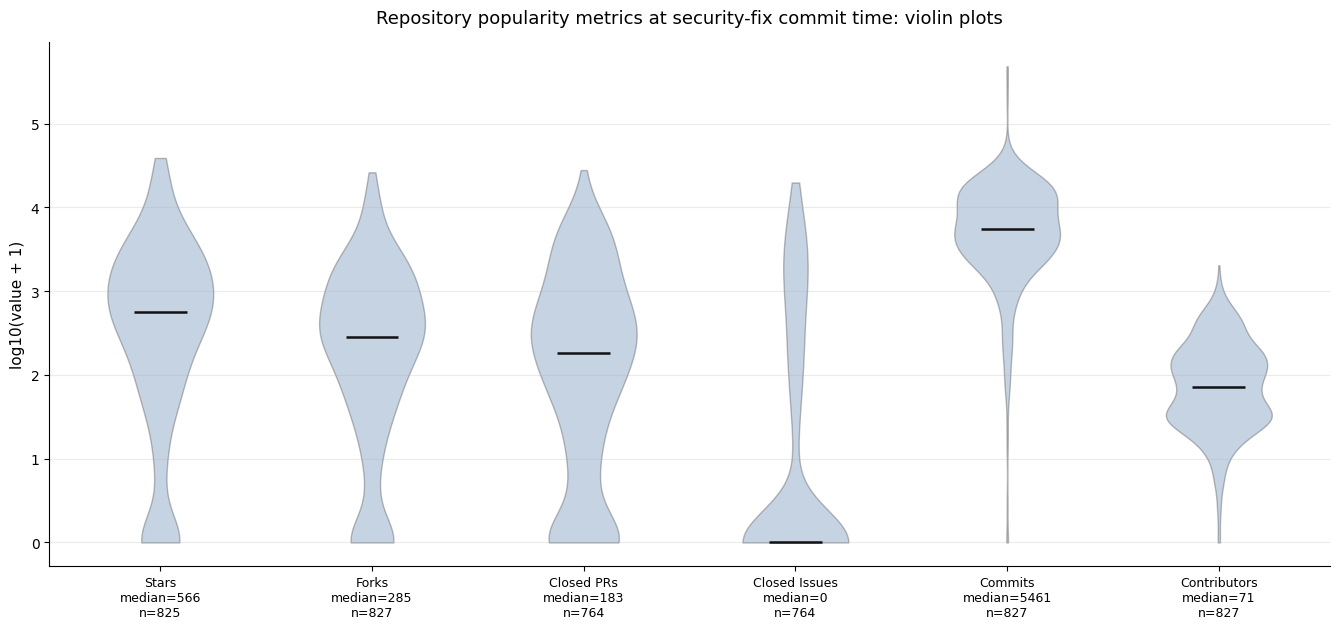

In [19]:
metric_order = list(metric_columns.keys())
metric_display_labels = []
violin_data = []

for metric in metric_order:
    raw_values = popularity_long_df.loc[popularity_long_df['Metric'].eq(metric), 'value'].dropna()
    log_values = np.log10(raw_values + 1)
    violin_data.append(log_values)
    median_value = raw_values.median()
    metric_display_labels.append(f'{metric}\nmedian={median_value:.0f}\nn={len(raw_values)}')

fig, ax = plt.subplots(figsize=(13.5, 6.4))
violins = ax.violinplot(
    violin_data,
    showmeans=False,
    showmedians=True,
    showextrema=False,
)

for body in violins['bodies']:
    body.set_facecolor('#4c78a8')
    body.set_edgecolor('#333333')
    body.set_alpha(0.32)

violins['cmedians'].set_color('#111111')
violins['cmedians'].set_linewidth(1.8)

ax.set_xticks(range(1, len(metric_display_labels) + 1))
ax.set_xticklabels(metric_display_labels, fontsize=9)
ax.set_ylabel('log10(value + 1)', fontsize=11)
ax.set_title('Repository popularity metrics at security-fix commit time: violin plots', fontsize=13, pad=14)
ax.grid(axis='y', alpha=0.25)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

## Boxplot: All Metrics

The y-axis uses `log10(value + 1)`. Median values shown in labels are raw counts.

/var/folders/49/199vrwcn1zqb7rx4rgy0xhbr0000gn/T/ipykernel_85895/1319416373.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


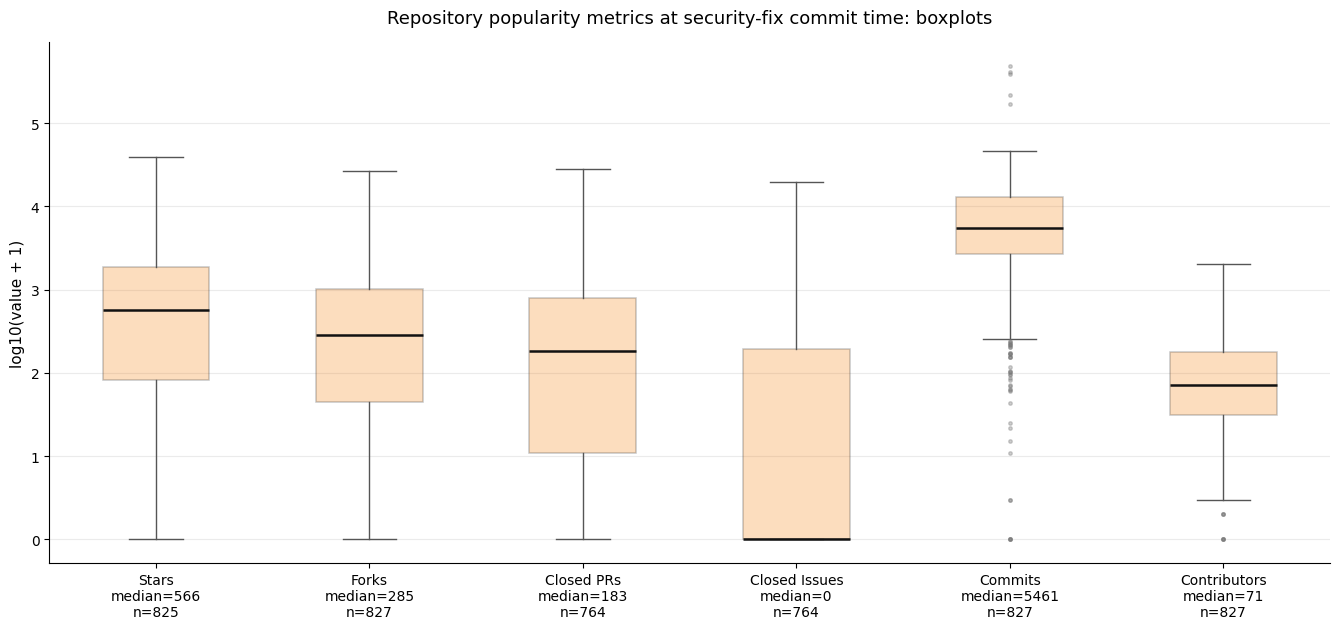

In [20]:
fig, ax = plt.subplots(figsize=(13.5, 6.4))
box = ax.boxplot(
    violin_data,
    labels=metric_display_labels,
    patch_artist=True,
    showfliers=True,
    medianprops={'color': '#111111', 'linewidth': 1.8},
    boxprops={'linewidth': 1.1, 'color': '#333333'},
    whiskerprops={'linewidth': 1.0, 'color': '#555555'},
    capprops={'linewidth': 1.0, 'color': '#555555'},
    flierprops={'marker': 'o', 'markersize': 2.5, 'markerfacecolor': '#777777', 'markeredgecolor': '#777777', 'alpha': 0.35},
)

for patch in box['boxes']:
    patch.set_facecolor('#f58518')
    patch.set_alpha(0.28)

ax.set_ylabel('log10(value + 1)', fontsize=11)
ax.set_title('Repository popularity metrics at security-fix commit time: boxplots', fontsize=13, pad=14)
ax.grid(axis='y', alpha=0.25)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

## Individual Violin + Boxplot Panels

Each metric gets its own panel with a violin and boxplot on the same log-scaled axis. This is useful when you want to inspect one metric at a time.

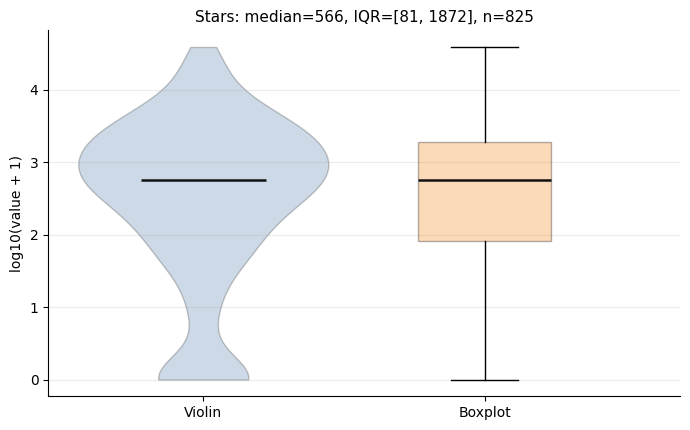

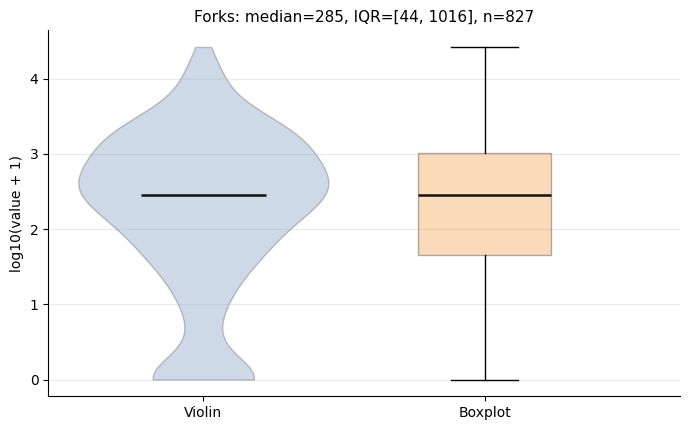

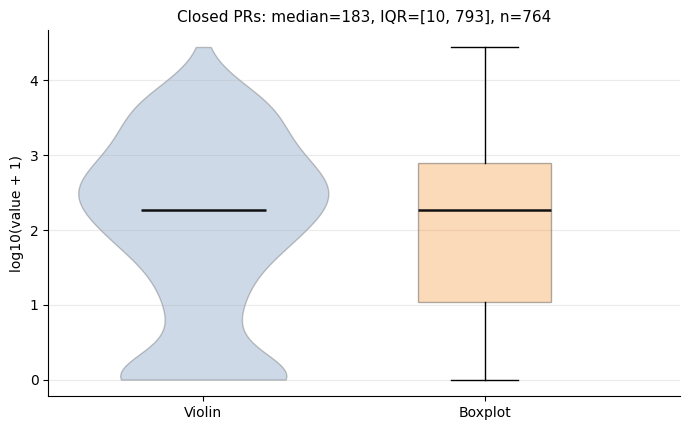

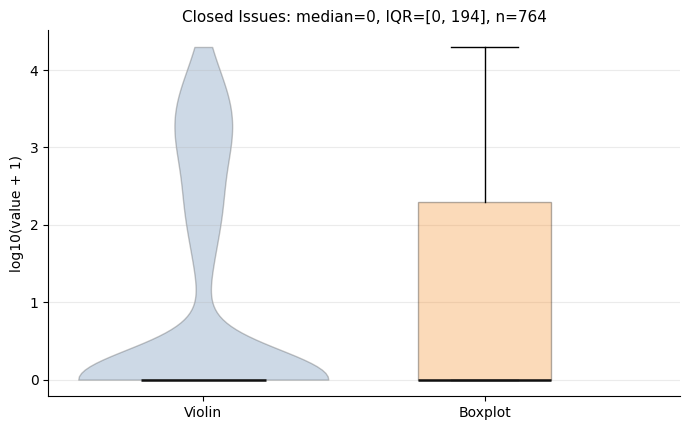

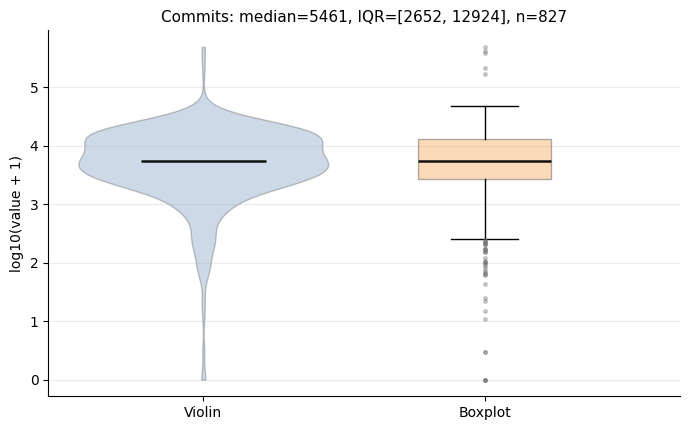

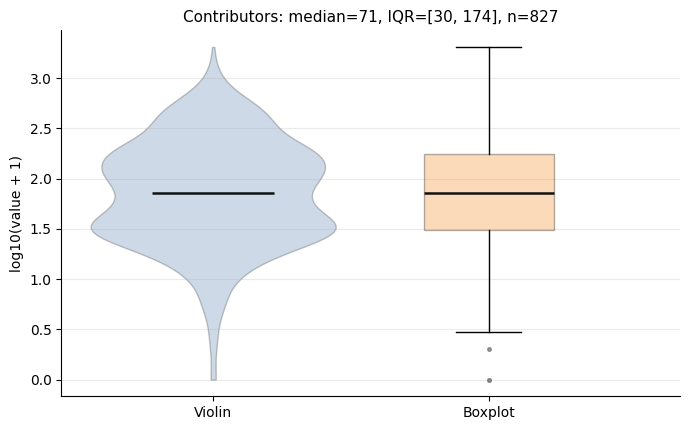

In [21]:
def plot_individual_metric_distribution(metric):
    values = popularity_long_df.loc[popularity_long_df['Metric'].eq(metric), 'value'].dropna()
    log_values = np.log10(values + 1)
    stats = metric_summary(values)

    fig, ax = plt.subplots(figsize=(7.0, 4.4))
    violin = ax.violinplot([log_values], positions=[1], widths=0.64, showmedians=True, showextrema=False)
    for body in violin['bodies']:
        body.set_facecolor('#4c78a8')
        body.set_edgecolor('#333333')
        body.set_alpha(0.28)
    violin['cmedians'].set_color('#111111')
    violin['cmedians'].set_linewidth(1.8)

    box = ax.boxplot(
        [log_values],
        positions=[1.72],
        widths=0.34,
        patch_artist=True,
        showfliers=True,
        medianprops={'color': '#111111', 'linewidth': 1.8},
        flierprops={'marker': 'o', 'markersize': 2.5, 'markerfacecolor': '#777777', 'markeredgecolor': '#777777', 'alpha': 0.35},
    )
    for patch in box['boxes']:
        patch.set_facecolor('#f58518')
        patch.set_alpha(0.30)

    ax.set_xticks([1, 1.72])
    ax.set_xticklabels(['Violin', 'Boxplot'])
    ax.set_ylabel('log10(value + 1)')
    ax.set_title(f'{metric}: median={stats["median"]:.0f}, IQR=[{stats["q1"]:.0f}, {stats["q3"]:.0f}], n={stats["n"]}', fontsize=11)
    ax.grid(axis='y', alpha=0.25)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    plt.show()


for metric in metric_order:
    plot_individual_metric_distribution(metric)

## Horizontal Boxplots by Repository Reporting Behavior

This section uses the same repository behavior definition as `rq1_repo_level_reporting_visual.ipynb`:
- `Only transparent fixes`
- `Only silent fixes`
- `Mixed silent and transparent fixes`

Metrics remain CVE/fix-instance level: each CVE fix contributes one popularity measurement, and the repository behavior label comes from the repository-level reporting behavior classification.

In [22]:
REPORTING_DATA_PATH = Path('../../data/rq1/corrected_resolved_links_v2.csv')
reporting_df = pd.read_csv(REPORTING_DATA_PATH)


def extract_repo(patch):
    if pd.isna(patch):
        return None
    match = re.search(r'https://github\.com/([^/]+/[^/\s]+)', str(patch))
    return match.group(1).lower() if match else None


reporting_df['repository'] = reporting_df['PATCH'].apply(extract_repo)
reporting_df['reporting_visibility'] = reporting_df['Link Presence'].map({
    'contains links': 'Transparent',
    'no links': 'Silent',
})

repo_counts = (
    reporting_df
    .groupby(['repository', 'reporting_visibility'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['Silent', 'Transparent']:
    if col not in repo_counts.columns:
        repo_counts[col] = 0

repo_counts['total_cves'] = repo_counts['Silent'] + repo_counts['Transparent']
repo_counts['repo_reporting_behavior'] = 'Mixed silent and transparent fixes'
repo_counts.loc[(repo_counts['Silent'] > 0) & (repo_counts['Transparent'] == 0), 'repo_reporting_behavior'] = 'Only silent fixes'
repo_counts.loc[(repo_counts['Silent'] == 0) & (repo_counts['Transparent'] > 0), 'repo_reporting_behavior'] = 'Only transparent fixes'

behavior_order = [
    'Only transparent fixes',
    'Only silent fixes',
    'Mixed silent and transparent fixes',
]

repo_behavior_for_merge = repo_counts[['repository', 'repo_reporting_behavior']].copy()
popularity_with_behavior_df = popularity_df.copy()
popularity_with_behavior_df['repository'] = popularity_with_behavior_df['repository'].str.lower()
popularity_with_behavior_df = popularity_with_behavior_df.merge(
    repo_behavior_for_merge,
    on='repository',
    how='left',
)

print('Popularity rows:', len(popularity_with_behavior_df))
print('Missing repository behavior:', popularity_with_behavior_df['repo_reporting_behavior'].isna().sum())
print('Repository behavior counts at CVE/fix-instance level:')
print(popularity_with_behavior_df['repo_reporting_behavior'].value_counts(dropna=False).reindex(behavior_order))

repo_counts[['repository', 'Silent', 'Transparent', 'total_cves', 'repo_reporting_behavior']].head()

Popularity rows: 832
Missing repository behavior: 0
Repository behavior counts at CVE/fix-instance level:
repo_reporting_behavior
Only transparent fixes                195
Only silent fixes                     147
Mixed silent and transparent fixes    490
Name: count, dtype: int64


reporting_visibility,repository,Silent,Transparent,total_cves,repo_reporting_behavior
0,acra/acra,1,0,1,Only silent fixes
1,alibaba/fastjson,0,1,1,Only transparent fixes
2,alkacon/opencms-core,5,1,6,Mixed silent and transparent fixes
3,apache/activemq,2,13,15,Mixed silent and transparent fixes
4,apache/activemq-apollo,0,1,1,Only transparent fixes


### Median/IQR by Repository Reporting Behavior

In [23]:
behavior_metric_summary_rows = []
for metric, column in metric_columns.items():
    for behavior in behavior_order:
        values = popularity_with_behavior_df.loc[
            popularity_with_behavior_df['repo_reporting_behavior'].eq(behavior),
            column,
        ].dropna()
        if values.empty:
            behavior_metric_summary_rows.append({
                'Metric': metric,
                'Repository reporting behavior': behavior,
                'n': 0,
                'Median': np.nan,
                'IQR': 'NA',
                'Q1': np.nan,
                'Q3': np.nan,
            })
            continue
        behavior_metric_summary_rows.append({
            'Metric': metric,
            'Repository reporting behavior': behavior,
            'n': int(len(values)),
            'Median': values.median(),
            'IQR': f'[{values.quantile(0.25):.2f}, {values.quantile(0.75):.2f}]',
            'Q1': values.quantile(0.25),
            'Q3': values.quantile(0.75),
        })

behavior_metric_median_iqr_table = pd.DataFrame(behavior_metric_summary_rows)
behavior_metric_median_iqr_table

,Metric,Repository reporting behavior,n,Median,IQR,Q1,Q3
0,Stars,Only transparent fixes,190,160.0,"[25.25, 1328.75]",25.25,1328.75
1,Stars,Only silent fixes,146,321.5,"[45.25, 959.75]",45.25,959.75
2,Stars,Mixed silent and transparent fixes,489,721.0,"[185.00, 2499.00]",185.00,2499.00
3,Forks,Only transparent fixes,191,83.0,"[14.00, 497.00]",14.00,497.00
4,Forks,Only silent fixes,146,156.0,"[27.50, 410.25]",27.50,410.25
5,Forks,Mixed silent and transparent fixes,490,434.5,"[100.75, 1448.50]",100.75,1448.50
6,Closed PRs,Only transparent fixes,181,71.0,"[1.00, 387.00]",1.00,387.00
7,Closed PRs,Only silent fixes,123,101.0,"[9.50, 397.00]",9.50,397.00
8,Closed PRs,Mixed silent and transparent fixes,460,238.5,"[37.75, 1262.00]",37.75,1262.00
9,Closed Issues,Only transparent fixes,181,0.0,"[0.00, 417.00]",0.00,417.00


### Separate Horizontal Boxplots by Repository Reporting Behavior

Each metric is shown in a separate figure. The x-axis uses `log10(value + 1)`, and the raw median is written directly on the corresponding behavior row.

/var/folders/49/199vrwcn1zqb7rx4rgy0xhbr0000gn/T/ipykernel_85895/2493239058.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


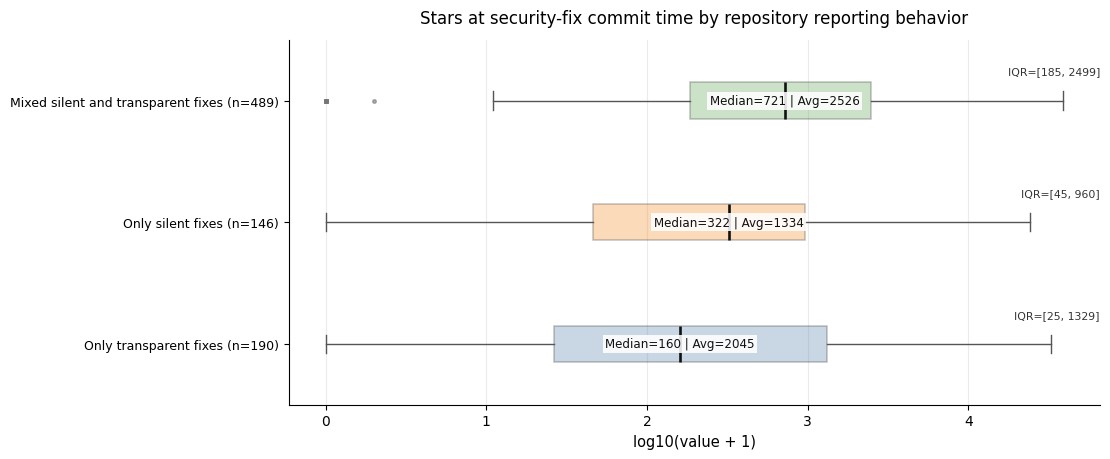

/var/folders/49/199vrwcn1zqb7rx4rgy0xhbr0000gn/T/ipykernel_85895/2493239058.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


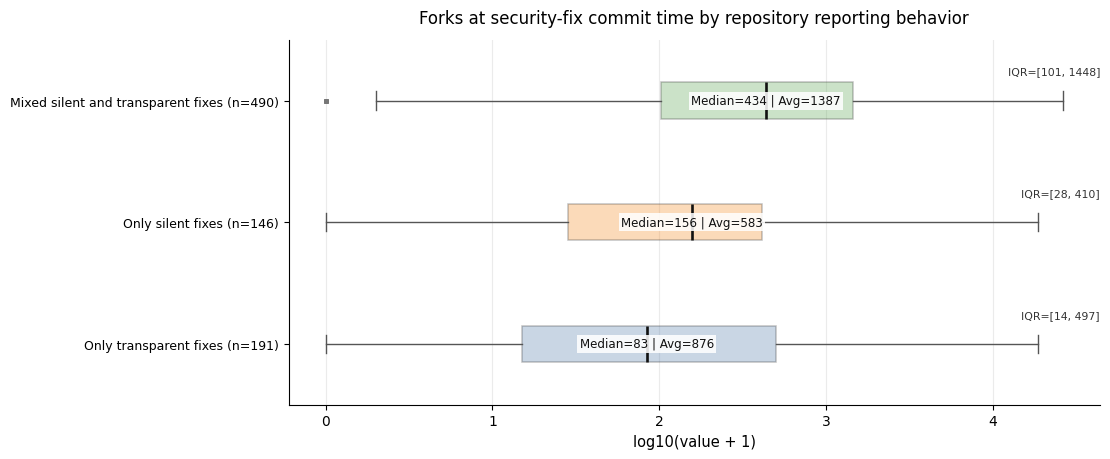

/var/folders/49/199vrwcn1zqb7rx4rgy0xhbr0000gn/T/ipykernel_85895/2493239058.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


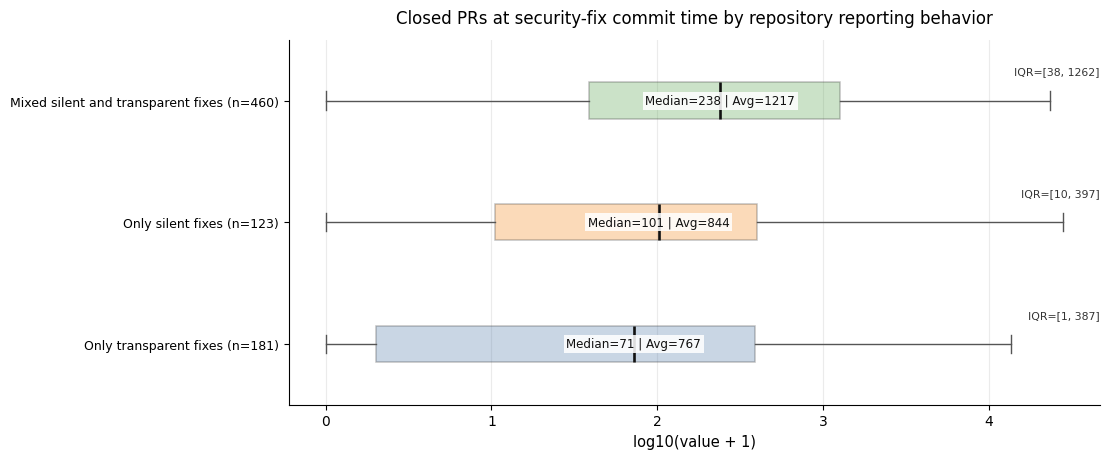

/var/folders/49/199vrwcn1zqb7rx4rgy0xhbr0000gn/T/ipykernel_85895/2493239058.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


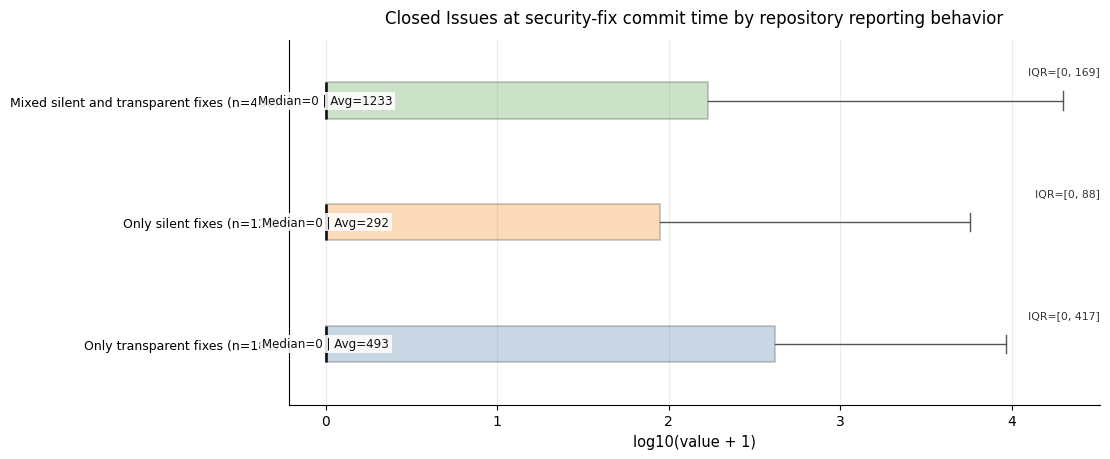

/var/folders/49/199vrwcn1zqb7rx4rgy0xhbr0000gn/T/ipykernel_85895/2493239058.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


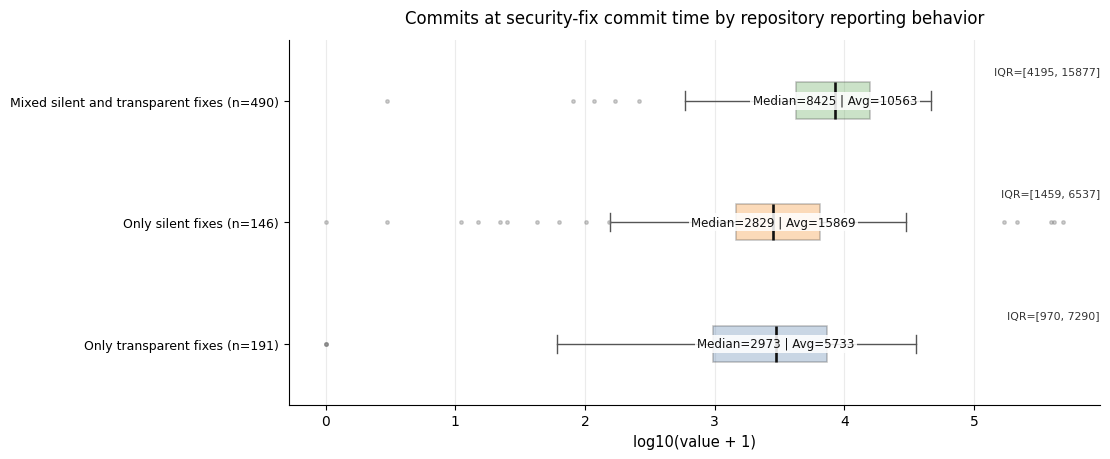

/var/folders/49/199vrwcn1zqb7rx4rgy0xhbr0000gn/T/ipykernel_85895/2493239058.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


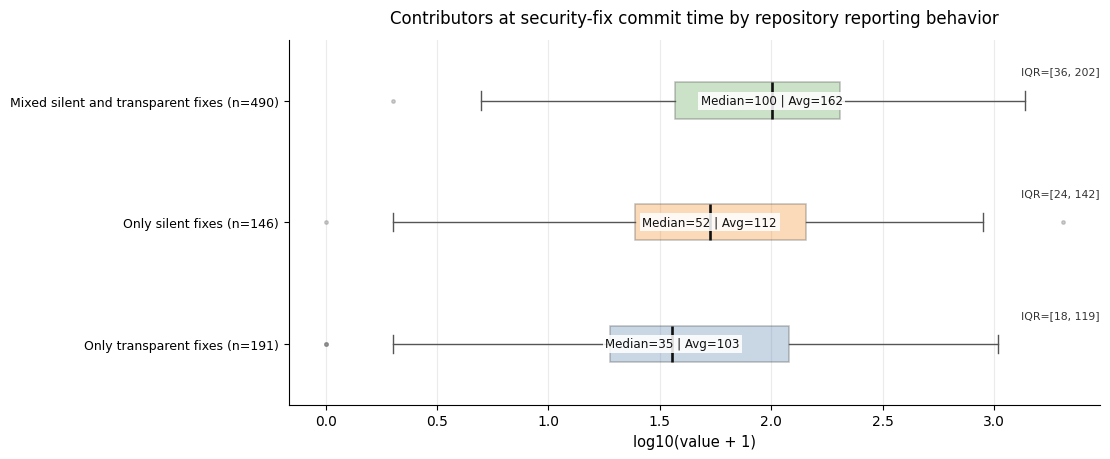

In [24]:
metric_order = list(metric_columns.keys())

behavior_colors = {
    'Only transparent fixes': '#4c78a8',
    'Only silent fixes': '#f58518',
    'Mixed silent and transparent fixes': '#54a24b',
}


def horizontal_boxplot_by_behavior(metric):
    column = metric_columns[metric]
    data = []
    labels = []
    colors = []
    raw_medians = []
    raw_means = []
    raw_q1 = []
    raw_q3 = []
    ns = []

    for behavior in behavior_order:
        values = popularity_with_behavior_df.loc[
            popularity_with_behavior_df['repo_reporting_behavior'].eq(behavior),
            column,
        ].dropna()
        log_values = np.log10(values + 1)
        data.append(log_values)
        raw_medians.append(values.median() if len(values) else np.nan)
        raw_means.append(values.mean() if len(values) else np.nan)
        raw_q1.append(values.quantile(0.25) if len(values) else np.nan)
        raw_q3.append(values.quantile(0.75) if len(values) else np.nan)
        ns.append(len(values))
        labels.append(f'{behavior} (n={len(values)})')
        colors.append(behavior_colors[behavior])

    fig, ax = plt.subplots(figsize=(11.2, 4.7))
    box = ax.boxplot(
        data,
        vert=False,
        labels=labels,
        patch_artist=True,
        showfliers=True,
        medianprops={'color': '#111111', 'linewidth': 1.9},
        boxprops={'linewidth': 1.1, 'color': '#333333'},
        whiskerprops={'linewidth': 1.0, 'color': '#555555'},
        capprops={'linewidth': 1.0, 'color': '#555555'},
        flierprops={
            'marker': 'o',
            'markersize': 2.5,
            'markerfacecolor': '#777777',
            'markeredgecolor': '#777777',
            'alpha': 0.35,
        },
    )

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.30)

    # Write raw median values directly on the plot at the log-scaled median position.
    for y_pos, median_value, mean_value, q1_value, q3_value in zip(range(1, len(behavior_order) + 1), raw_medians, raw_means, raw_q1, raw_q3):
        if pd.isna(median_value):
            continue
        median_x = np.log10(median_value + 1)
        ax.text(
            median_x,
            y_pos,
            f'Median={median_value:.0f} | Avg={mean_value:.0f}',
            ha='center',
            va='center',
            fontsize=8.6,
            color='#111111',
            bbox={
                'facecolor': 'white',
                'edgecolor': 'none',
                'alpha': 0.86,
                'pad': 1.8,
            },
            zorder=6,
        )

        # Put IQR as a small note near the right side of each row for context.
        x_right = ax.get_xlim()[1]
        ax.text(
            x_right,
            y_pos + 0.24,
            f'IQR=[{q1_value:.0f}, {q3_value:.0f}]',
            ha='right',
            va='center',
            fontsize=7.8,
            color='#333333',
            bbox={
                'facecolor': 'white',
                'edgecolor': 'none',
                'alpha': 0.78,
                'pad': 1.0,
            },
            zorder=6,
        )

    ax.set_xlabel('log10(value + 1)', fontsize=10.5)
    ax.set_title(f'{metric} at security-fix commit time by repository reporting behavior', fontsize=12, pad=12)
    ax.grid(axis='x', alpha=0.25)
    ax.tick_params(axis='y', labelsize=9)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    plt.show()


for metric in metric_order:
    horizontal_boxplot_by_behavior(metric)

In [25]:
repo_level_df = popularity_df.copy()
repo_level_df['commit_time_parsed'] = pd.to_datetime(repo_level_df['commit_time'], errors='coerce', utc=True)
repo_level_df = repo_level_df.sort_values(['repository', 'commit_time_parsed']).drop_duplicates(subset=['repository'], keep='first')

repo_summary_rows = []
for metric, column in metric_columns.items():
    stats = metric_summary(repo_level_df[column])
    repo_summary_rows.append({
        'Metric': metric,
        'n repositories': stats['n'],
        'Median': stats['median'],
        'IQR': f"[{stats['q1']:.2f}, {stats['q3']:.2f}]",
        'Q1': stats['q1'],
        'Q3': stats['q3'],
        'Mean': stats['mean'],
        'Min': stats['min'],
        'Max': stats['max'],
    })

repo_level_popularity_median_iqr_table = pd.DataFrame(repo_summary_rows)
repo_level_popularity_median_iqr_table

,Metric,n repositories,Median,IQR,Q1,Q3,Mean,Min,Max
0,Stars,254,200.5,"[21.25, 1099.50]",21.25,1099.5,1701.492126,0.0,30932.0
1,Forks,255,113.0,"[11.00, 473.50]",11.00,473.5,713.992157,0.0,18519.0
2,Closed PRs,227,88.0,"[2.00, 583.00]",2.00,583.0,775.405286,0.0,27943.0
3,Closed Issues,227,0.0,"[0.00, 368.50]",0.00,368.5,482.916300,0.0,9112.0
4,Commits,255,2529.0,"[1038.00, 5895.00]",1038.00,5895.0,6313.290196,0.0,215641.0
5,Contributors,255,42.0,"[19.00, 122.00]",19.00,122.0,104.400000,0.0,2044.0


In [26]:
# No CSV or image files are saved by default. Uncomment only if needed.
# popularity_median_iqr_table.to_csv('repo_popularity_metric_median_iqr_table.csv', index=False)
# repo_level_popularity_median_iqr_table.to_csv('repo_level_popularity_metric_median_iqr_table.csv', index=False)